In [1]:
import torch
dataset = torch.load("van_der_pol_train.pt", weights_only=False)
print(f"Mean SQP cost: {dataset['costs'].mean():.2f}")
print(f"Min SQP cost:  {dataset['costs'].min():.2f}")
print(f"Max SQP cost:  {dataset['costs'].max():.2f}")

Mean SQP cost: 410.27
Min SQP cost:  0.03
Max SQP cost:  1442.85


In [1]:
import torch
import numpy as np

dataset = torch.load("van_der_pol_train.pt", weights_only=False)
costs = dataset['costs']

print(f"Mean SQP cost: {costs.mean():.2f}")
print(f"Std  SQP cost: {costs.std():.2f}")
print(f"Min  SQP cost: {costs.min():.2f}")
print(f"Max  SQP cost: {costs.max():.2f}")

Mean SQP cost: 410.27
Std  SQP cost: 294.02
Min  SQP cost: 0.03
Max  SQP cost: 1442.85


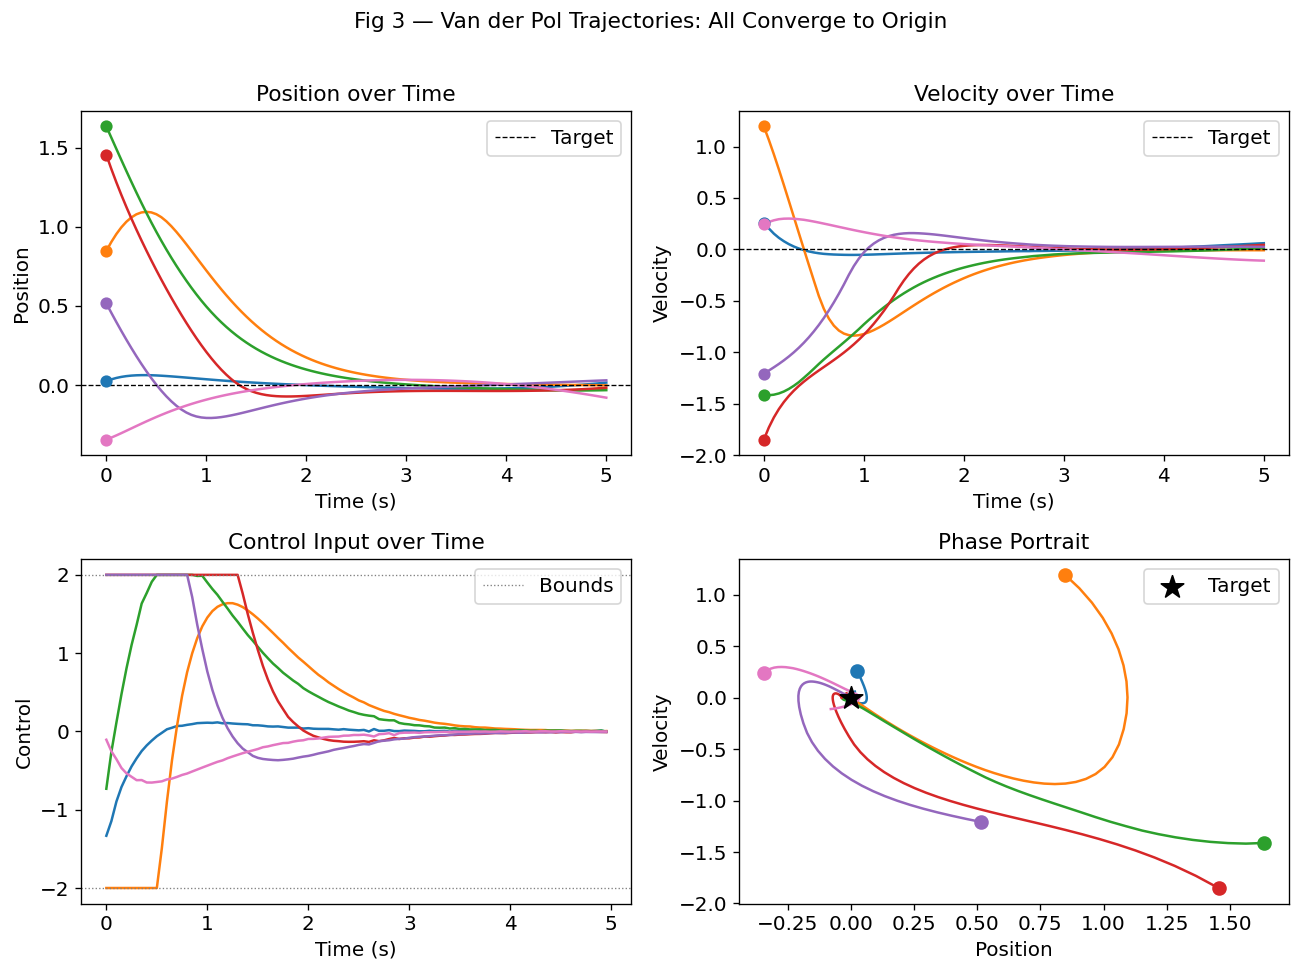

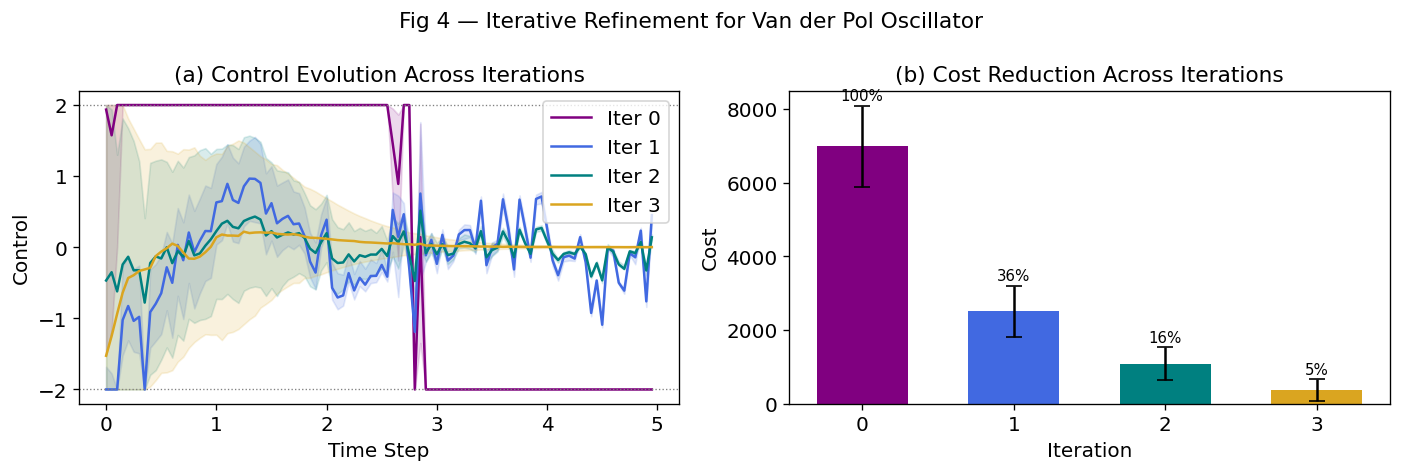

Cost reduction summary:
  Iter 0: mean cost = 6985.05  (100.0% of iter 0)
  Iter 1: mean cost = 2509.19  (35.9% of iter 0)
  Iter 2: mean cost = 1083.03  (15.5% of iter 0)
  Iter 3: mean cost = 376.52  (5.4% of iter 0)


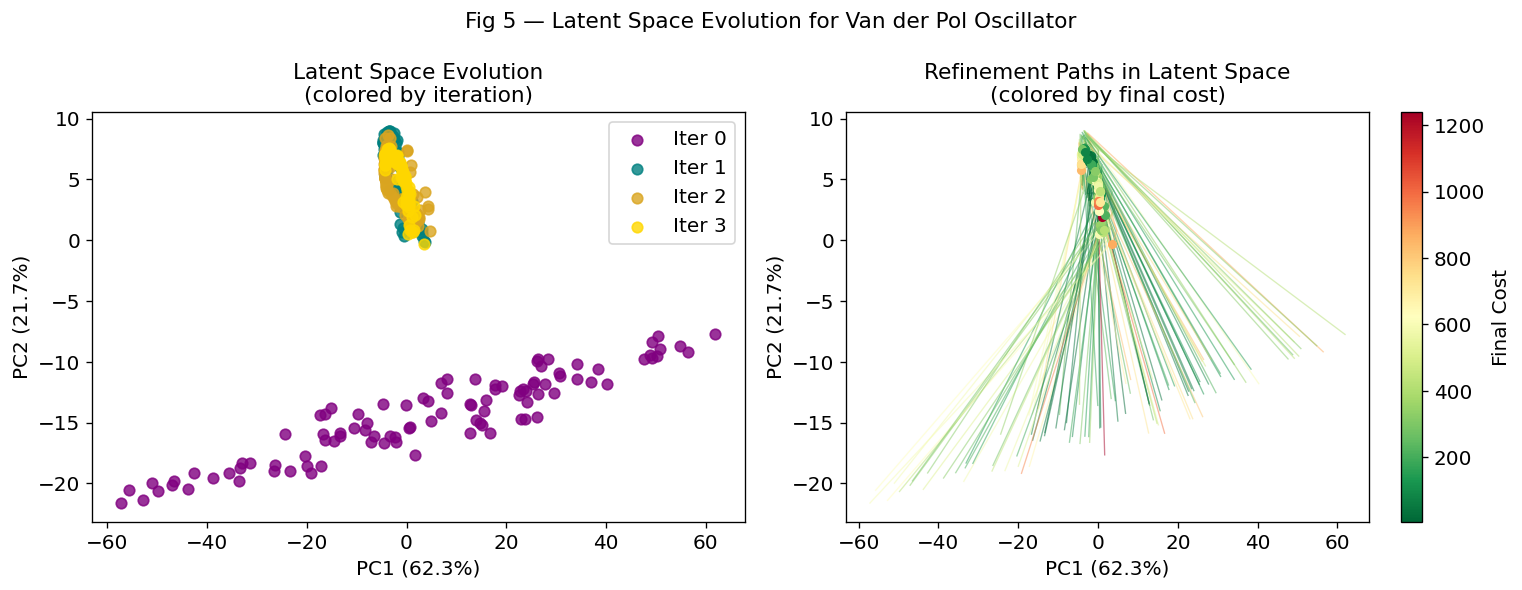

PCA explained variance: PC1=62.3%  PC2=21.7%


In [4]:
# %% [markdown]
# # TRC Results Visualization
# Reproduces Figures 2, 3, 4, and 5 from Jain & Linares (2026)

# %% Imports and setup
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader

from trc import TRC
from train import VanDerPolDataset, CONFIG

plt.rcParams.update({
    "font.size":        12,
    "axes.titlesize":   13,
    "axes.labelsize":   12,
    "figure.dpi":       120,
    "lines.linewidth":  1.5,
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# %% Load model and dataset
checkpoint = torch.load("trc_checkpoint.pt", weights_only=False)
config     = checkpoint["config"]

model = TRC(
    d_x      = config["d_x"],
    d_u      = config["d_u"],
    T        = config["T"],
    K        = config["K"],
    n        = config["n"],
    d_z      = config["d_z"],
    d_h      = config["d_h"],
    L        = config["L"],
    num_heads= config["num_heads"],
    u_min    = config["u_min"],
    u_max    = config["u_max"],
).to(device)

model.load_state_dict(checkpoint["model_state"])
model.eval()

Q  = config["Q"].to(device)
Qf = config["Qf"].to(device)
R  = config["R"]
K  = config["K"]
T  = config["T"]
dt = 0.05
time_axis = np.arange(T) * dt   # 0..4.95 seconds

test_dataset = VanDerPolDataset("van_der_pol_test.pt")
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

raw_test  = torch.load("van_der_pol_test.pt",  weights_only=False)
sqp_costs = raw_test["costs"]


# ============================================================
# FIGURE 2 — Training convergence
# Requires training history saved during train.py
# Add this to your train.py to save history:
#
#   history = {"train_loss": [], "train_impr": [],
#              "val_loss":   [], "val_impr":   []}
#   # inside epoch loop, after computing metrics:
#   history["train_loss"].append(train_loss)
#   history["train_impr"].append(train_impr)
#   history["val_loss"].append(val_loss)
#   history["val_impr"].append(val_impr)
#   # after training loop:
#   torch.save(history, "training_history.pt")
# ============================================================

# # %% Figure 2 — Training convergence
# history = torch.load("training_history.pt", weights_only=False)

# epochs     = range(1, len(history["train_loss"]) + 1)
# train_loss = history["train_loss"]
# val_loss   = history["val_loss"]
# train_impr = history["train_impr"]
# val_impr   = history["val_impr"]

# fig, ax1 = plt.subplots(figsize=(8, 4))

# # Control loss on left axis
# ax1.set_xlabel("Epoch")
# ax1.set_ylabel("Control Loss (MSE)", color="royalblue")
# ax1.semilogy(epochs, train_loss, color="royalblue",      label="Train Control Loss")
# ax1.semilogy(epochs, val_loss,   color="royalblue",
#              linestyle="--", label="Val Control Loss")
# ax1.tick_params(axis="y", labelcolor="royalblue")

# # Improvement metric on right axis
# ax2 = ax1.twinx()
# ax2.set_ylabel("Improvement", color="green")
# ax2.plot(epochs, train_impr, color="green",     label="Train Improvement")
# ax2.plot(epochs, val_impr,   color="green",
#          linestyle="--", label="Val Improvement")
# ax2.tick_params(axis="y", labelcolor="green")
# ax2.set_ylim(0, 0.4)

# # Combined legend
# lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right", fontsize=9)

# ax1.set_title("Van der Pol Oscillator Training Convergence")
# fig.tight_layout()
# plt.savefig("fig2_training_convergence.png", dpi=150, bbox_inches="tight")
# plt.show()


# ============================================================
# FIGURE 3 — Trajectory results
# Runs TRC on a selection of test samples and plots
# position, velocity, control over time, and phase portrait
# ============================================================

# %% Collect trajectories for Figure 3
N_TRAJ = 6   # number of trajectories to plot — paper shows ~6 colors

# Pick N_TRAJ samples spread across the test set for variety
indices  = torch.linspace(0, len(test_dataset) - 1, N_TRAJ).long()
x0_plot  = raw_test["x0"][indices].to(device)       # (N_TRAJ, 2)
xt_plot  = raw_test["x_target"][indices].to(device)  # (N_TRAJ, 2)

with torch.no_grad():
    u_final = model(
        x0_plot, xt_plot,
        dynamics_fn=model.van_der_pol.simulate,
        return_all_iters=False,
    )                                                 # (N_TRAJ, T, 1)
    full_traj = model.van_der_pol.traj(x0_plot, u_final)  # (N_TRAJ, T+1, 2)

full_traj = full_traj.cpu().numpy()   # (N_TRAJ, T+1, 2)
u_final   = u_final.cpu().numpy()     # (N_TRAJ, T, 1)
x0_np     = x0_plot.cpu().numpy()

colors = plt.cm.tab10(np.linspace(0, 0.6, N_TRAJ))
time_traj = np.arange(T + 1) * dt    # 0..5.0 seconds

# %% Figure 3 — four panel plot
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

ax_pos, ax_vel   = axes[0]
ax_ctrl, ax_phase = axes[1]

for i in range(N_TRAJ):
    c = colors[i]
    # Starting point marker
    ax_pos.scatter(0, full_traj[i, 0, 0], color=c, s=40, zorder=5)
    ax_vel.scatter(0, full_traj[i, 0, 1], color=c, s=40, zorder=5)

    ax_pos.plot(time_traj,  full_traj[i, :, 0], color=c)
    ax_vel.plot(time_traj,  full_traj[i, :, 1], color=c)
    ax_ctrl.plot(time_axis, u_final[i, :, 0],   color=c)
    ax_phase.scatter(x0_np[i, 0], x0_np[i, 1],  color=c, s=60, zorder=5)
    ax_phase.plot(full_traj[i, :, 0], full_traj[i, :, 1], color=c)

# Target markers
ax_pos.axhline(0,  color="k", linestyle="--", linewidth=0.8, label="Target")
ax_vel.axhline(0,  color="k", linestyle="--", linewidth=0.8, label="Target")
ax_phase.scatter(0, 0, color="k", marker="*", s=200, zorder=6, label="Target")

ax_pos.set_xlabel("Time (s)"); ax_pos.set_ylabel("Position")
ax_pos.set_title("Position over Time"); ax_pos.legend()

ax_vel.set_xlabel("Time (s)"); ax_vel.set_ylabel("Velocity")
ax_vel.set_title("Velocity over Time"); ax_vel.legend()

ax_ctrl.set_xlabel("Time (s)"); ax_ctrl.set_ylabel("Control")
ax_ctrl.set_title("Control Input over Time")
ax_ctrl.axhline( 2.0, color="gray", linestyle=":", linewidth=0.8, label="Bounds")
ax_ctrl.axhline(-2.0, color="gray", linestyle=":", linewidth=0.8)
ax_ctrl.legend()

ax_phase.set_xlabel("Position"); ax_phase.set_ylabel("Velocity")
ax_phase.set_title("Phase Portrait")
ax_phase.legend()

fig.suptitle(
    "Fig 3 — Van der Pol Trajectories: All Converge to Origin",
    fontsize=13, y=1.01
)
fig.tight_layout()
plt.savefig("fig3_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()


# ============================================================
# FIGURE 4 — Iterative refinement
# (a) Control evolution across iterations — mean + percentile bands
# (b) Cost reduction bar chart
# ============================================================

# %% Collect all_u and per-iteration costs for Figure 4
N_EVAL   = 200   # number of test samples to use
x0_eval  = raw_test["x0"][:N_EVAL].to(device)
xt_eval  = raw_test["x_target"][:N_EVAL].to(device)

with torch.no_grad():
    all_u = model(
        x0_eval, xt_eval,
        dynamics_fn=model.van_der_pol.simulate,
        return_all_iters=True,
    )   # list of K+1 tensors, each (N_EVAL, T, 1)

# Per-iteration costs
iter_costs = []
for u_k in all_u:
    traj_k = model.van_der_pol.traj(x0_eval, u_k)
    J_k    = model.cost(traj_k, u_k, Q, R, Qf).cpu().numpy()  # (N_EVAL,)
    iter_costs.append(J_k)

all_u_np = [u.cpu().numpy() for u in all_u]  # list of (N_EVAL, T, 1)

# %% Figure 4 — two panel
iter_colors = ["purple", "royalblue", "teal", "goldenrod"]
iter_labels = [f"Iter {k}" for k in range(K + 1)]

fig, (ax_ctrl, ax_cost) = plt.subplots(1, 2, figsize=(12, 4))

# --- Panel (a): control evolution with percentile bands ---
for k in range(K + 1):
    u_k   = all_u_np[k][:, :, 0]          # (N_EVAL, T)
    med   = np.median(u_k, axis=0)
    p25   = np.percentile(u_k, 25, axis=0)
    p75   = np.percentile(u_k, 75, axis=0)
    c     = iter_colors[k]

    ax_ctrl.plot(time_axis, med, color=c, label=iter_labels[k])
    ax_ctrl.fill_between(time_axis, p25, p75, color=c, alpha=0.15)

ax_ctrl.set_xlabel("Time Step")
ax_ctrl.set_ylabel("Control")
ax_ctrl.set_title("(a) Control Evolution Across Iterations")
ax_ctrl.axhline( 2.0, color="gray", linestyle=":", linewidth=0.8)
ax_ctrl.axhline(-2.0, color="gray", linestyle=":", linewidth=0.8)
ax_ctrl.legend()

# --- Panel (b): cost reduction bar chart ---
mean_costs = [c.mean() for c in iter_costs]
std_costs  = [c.std()  for c in iter_costs]

bars = ax_cost.bar(
    range(K + 1), mean_costs,
    yerr=std_costs,
    color=iter_colors,
    capsize=5,
    width=0.6,
    error_kw={"linewidth": 1.5},
)
ax_cost.set_xlabel("Iteration")
ax_cost.set_ylabel("Cost")
ax_cost.set_title("(b) Cost Reduction Across Iterations")
ax_cost.set_xticks(range(K + 1))

# Annotate percentage reduction
for k in range(K + 1):
    pct = mean_costs[k] / mean_costs[0] * 100
    ax_cost.text(
        k, mean_costs[k] + std_costs[k] + mean_costs[0] * 0.02,
        f"{pct:.0f}%", ha="center", fontsize=9
    )

fig.suptitle(
    "Fig 4 — Iterative Refinement for Van der Pol Oscillator",
    fontsize=13
)
fig.tight_layout()
plt.savefig("fig4_iterative_refinement.png", dpi=150, bbox_inches="tight")
plt.show()

print("Cost reduction summary:")
for k in range(K + 1):
    pct = mean_costs[k] / mean_costs[0] * 100
    print(f"  Iter {k}: mean cost = {mean_costs[k]:.2f}  ({pct:.1f}% of iter 0)")


# ============================================================
# FIGURE 5 — Latent space evolution
# Requires hooking into TRC forward pass to extract z_H
# at each outer iteration
# ============================================================

# %% Hook to extract z_H at each iteration
# We modify the forward pass temporarily using a wrapper

class TRCWithLatents(torch.nn.Module):
    """
    Wraps TRC forward pass to extract z_H after each outer iteration.
    Stored in self.latent_history after each forward call.
    """
    def __init__(self, trc_model):
        super().__init__()
        self.model          = trc_model
        self.latent_history = []   # list of K+1 tensors (B, d_z)

    def forward(self, x0, x_target):
        self.latent_history = []
        B      = x0.shape[0]
        d_z    = self.model.d_z
        device = x0.device

        t_rem = torch.ones(B, 1, device=device) * self.model.T
        z0    = self.model.state_encoder(
            torch.cat([x0, x_target, t_rem], dim=-1)
        )
        z_H, z_L = self.model._init_latents(z0)

        # Record initial z_H before any refinement
        self.latent_history.append(z_H.cpu().numpy().copy())

        u = self.model.initial_decoder(z0).view(B, self.model.T, self.model.d_u)
        u = u.clamp(self.model.u_min, self.model.u_max)

        for k in range(self.model.K):
            x_T   = self.model.van_der_pol.simulate(x0, u)
            e     = x_T - x_target
            z_err = self.model.error_embed(e)
            z_ctrl= self.model.ctrl_embed(u.flatten(1))
            z_ctx = z0 + z_err + z_ctrl

            for _ in range(self.model.n):
                z_L = self.model.reasoning(z_L, z_H + z_ctx)

            z_H = self.model.reasoning(z_H, z_L)

            # Record z_H after this iteration
            self.latent_history.append(z_H.cpu().numpy().copy())

            delta_u = self.model.residual_decoder(
                torch.cat([z_H, u.flatten(1)], dim=-1)
            ).view(B, self.model.T, self.model.d_u)
            u = (u + delta_u).clamp(self.model.u_min, self.model.u_max)

        return u


# %% Collect latents and final costs
N_LATENT = 100
x0_lat   = raw_test["x0"][:N_LATENT].to(device)
xt_lat   = raw_test["x_target"][:N_LATENT].to(device)

wrapper = TRCWithLatents(model).to(device)
wrapper.eval()

with torch.no_grad():
    u_final_lat = wrapper(x0_lat, xt_lat)
    traj_lat    = model.van_der_pol.traj(x0_lat, u_final_lat)
    final_costs = model.cost(traj_lat, u_final_lat, Q, R, Qf).cpu().numpy()

# wrapper.latent_history: list of K+1 arrays, each (N_LATENT, d_z)
latents = wrapper.latent_history   # K+1 entries

# %% PCA on all latents combined
all_latents_stacked = np.vstack(latents)   # ((K+1)*N_LATENT, d_z)
pca = PCA(n_components=2)
pca.fit(all_latents_stacked)

# Project each iteration separately
latents_2d = [pca.transform(z) for z in latents]   # list of (N_LATENT, 2)

var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100

# %% Figure 5 — two panel
iter_colors_pca = ["purple", "teal", "goldenrod", "gold"]

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(13, 5))

# --- Left panel: colored by iteration ---
for k in range(K + 1):
    z2d = latents_2d[k]
    ax_left.scatter(
        z2d[:, 0], z2d[:, 1],
        color=iter_colors_pca[k],
        label=f"Iter {k}",
        s=40, alpha=0.8, zorder=3,
    )

ax_left.set_xlabel(f"PC1 ({var1:.1f}%)")
ax_left.set_ylabel(f"PC2 ({var2:.1f}%)")
ax_left.set_title("Latent Space Evolution\n(colored by iteration)")
ax_left.legend()

# --- Right panel: refinement paths colored by final cost ---
cost_min = final_costs.min()
cost_max = final_costs.max()
norm     = plt.Normalize(vmin=cost_min, vmax=cost_max)
cmap     = cm.RdYlGn_r   # red = high cost, green = low cost

for i in range(N_LATENT):
    # Draw arrow from iter 0 to iter K for sample i
    path_x = [latents_2d[k][i, 0] for k in range(K + 1)]
    path_y = [latents_2d[k][i, 1] for k in range(K + 1)]
    color  = cmap(norm(final_costs[i]))
    ax_right.plot(path_x, path_y, color=color, alpha=0.5, linewidth=0.8)
    ax_right.scatter(path_x[-1], path_y[-1], color=color, s=20, zorder=3)

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax_right)
cbar.set_label("Final Cost")

ax_right.set_xlabel(f"PC1 ({var1:.1f}%)")
ax_right.set_ylabel(f"PC2 ({var2:.1f}%)")
ax_right.set_title("Refinement Paths in Latent Space\n(colored by final cost)")

fig.suptitle(
    "Fig 5 — Latent Space Evolution for Van der Pol Oscillator",
    fontsize=13
)
fig.tight_layout()
plt.savefig("fig5_latent_space.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"PCA explained variance: PC1={var1:.1f}%  PC2={var2:.1f}%")

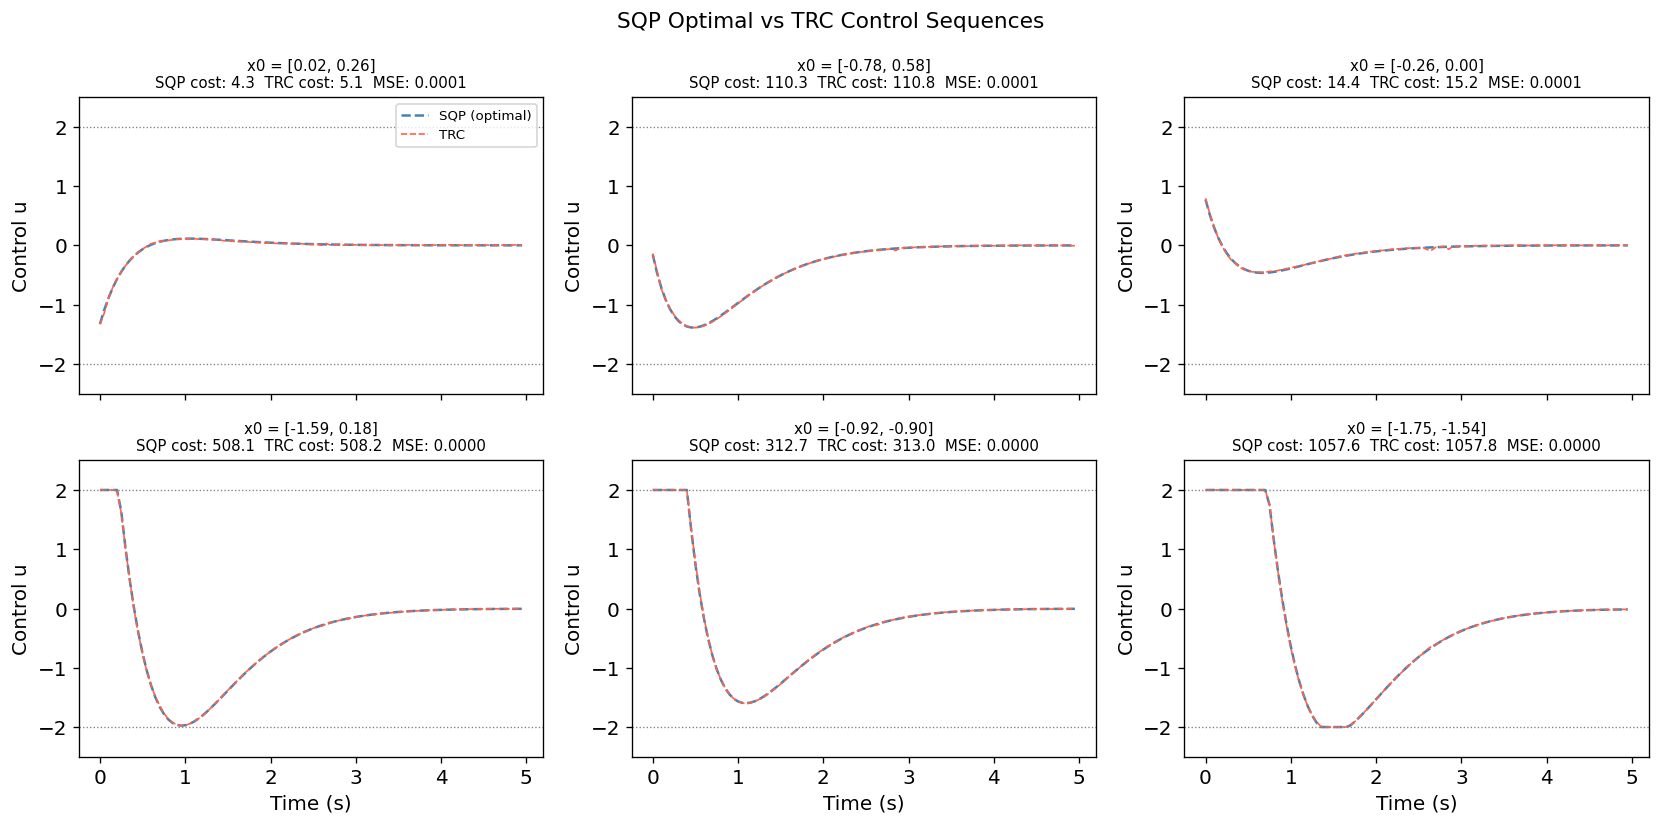

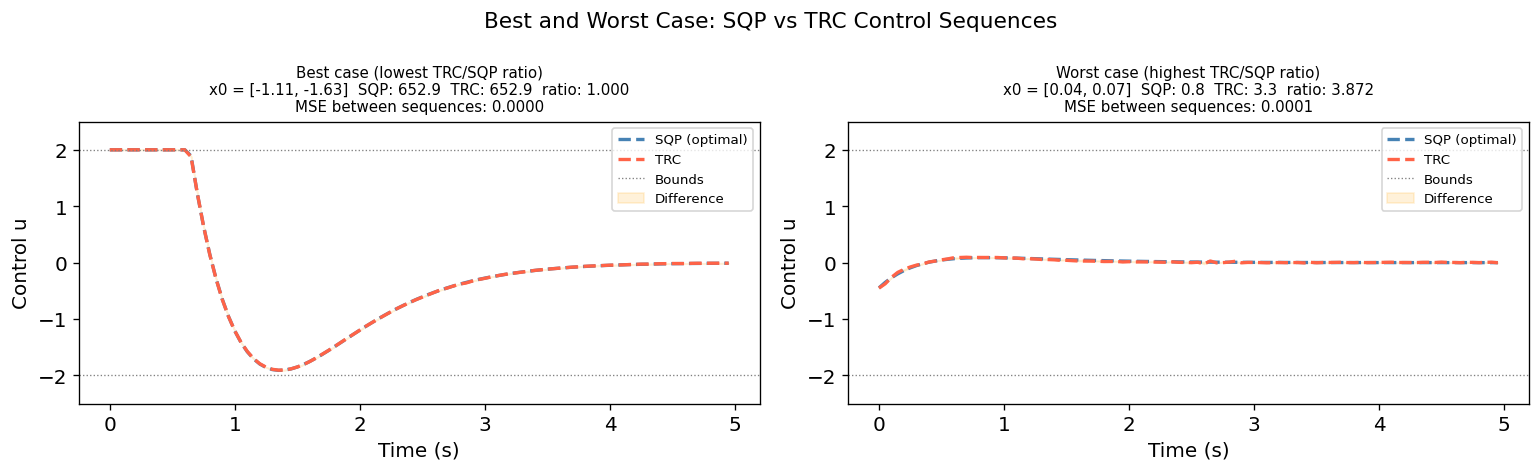

Best  case — idx: 690  ratio: 1.0000
Worst case — idx: 862  ratio: 3.8721
Mean ratio across test set: 1.0267


In [9]:
# %% SQP vs TRC Control Sequence Comparison

import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from trc import TRC
from train import VanDerPolDataset, CONFIG

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Load model ----
checkpoint = torch.load("trc_checkpoint.pt", weights_only=False)
config     = checkpoint["config"]

model = TRC(
    d_x      = config["d_x"],
    d_u      = config["d_u"],
    T        = config["T"],
    K        = config["K"],
    n        = config["n"],
    d_z      = config["d_z"],
    d_h      = config["d_h"],
    L        = config["L"],
    num_heads= config["num_heads"],
    u_min    = config["u_min"],
    u_max    = config["u_max"],
).to(device)

model.load_state_dict(checkpoint["model_state"])
model.eval()

Q  = config["Q"].to(device)
Qf = config["Qf"].to(device)
R  = config["R"]
T  = config["T"]
dt = 0.05
time_axis = np.arange(T) * dt   # 0..4.95 seconds

# ---- Load test dataset ----
raw_test = torch.load("van_der_pol_test.pt", weights_only=False)

# ---- Pick N samples to compare ----
# Choose a spread of interesting initial conditions
N_COMPARE = 10
indices = [0, 50, 100, 200, 400, 800]   # spread across test set

x0_sel     = raw_test["x0"][indices].to(device)         # (N, 2)
xt_sel     = raw_test["x_target"][indices].to(device)   # (N, 2)
u_sqp_sel  = raw_test["u_star"][indices]                 # (N, T, 1) — SQP optimal
x0_np      = raw_test["x0"][indices].numpy()

# ---- Run TRC ----
with torch.no_grad():
    all_u = model(
        x0_sel, xt_sel,
        dynamics_fn=model.van_der_pol.simulate,
        return_all_iters=True,
    )

u_trc_np = all_u[-1].cpu().numpy()    # (N, T, 1) — TRC final iteration
u_sqp_np = u_sqp_sel.numpy()          # (N, T, 1) — SQP optimal

# ---- Compute costs for annotation ----
with torch.no_grad():
    traj_trc = model.van_der_pol.traj(x0_sel, all_u[-1])
    cost_trc = model.cost(traj_trc, all_u[-1], Q, R, Qf).cpu().numpy()

sqp_costs_sel = raw_test["costs"][indices].numpy()

# ============================================================
# Plot 1 — Grid of N_COMPARE subplots, one per sample
# Each subplot: SQP (dashed) vs TRC (solid) control sequence
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    sqp_seq = u_sqp_np[i, :, 0]   # (T,)
    trc_seq = u_trc_np[i, :, 0]   # (T,)

    ax.plot(time_axis, sqp_seq, color="steelblue",
            linestyle="--", linewidth=1.5, label="SQP (optimal)")
    ax.plot(time_axis, trc_seq, color="tomato",
            linestyle="--",  linewidth=1.0, label="TRC")

    # Control bounds
    ax.axhline( 2.0, color="gray", linestyle=":", linewidth=0.8)
    ax.axhline(-2.0, color="gray", linestyle=":", linewidth=0.8)

    # MSE between the two sequences
    mse = np.mean((sqp_seq - trc_seq)**2)

    ax.set_title(
        f"x0 = [{x0_np[i,0]:.2f}, {x0_np[i,1]:.2f}]\n"
        f"SQP cost: {sqp_costs_sel[i]:.1f}  "
        f"TRC cost: {cost_trc[i]:.1f}  "
        f"MSE: {mse:.4f}",
        fontsize=9
    )
    ax.set_ylim(-2.5, 2.5)
    ax.set_ylabel("Control u")

    if i >= 3:
        ax.set_xlabel("Time (s)")

    if i == 0:
        ax.legend(fontsize=8, loc="upper right")

fig.suptitle(
    "SQP Optimal vs TRC Control Sequences",
    fontsize=13
)
fig.tight_layout()
plt.savefig("sqp_vs_trc_grid.png", dpi=150, bbox_inches="tight")
plt.show()


# ============================================================
# Plot 2 — Single best and worst case side by side
# Best = lowest TRC/SQP cost ratio
# Worst = highest TRC/SQP cost ratio
# ============================================================

# Find best and worst across full test set
N_FULL    = len(raw_test["x0"])
x0_full   = raw_test["x0"].to(device)
xt_full   = raw_test["x_target"].to(device)
u_sqp_full = raw_test["u_star"]

with torch.no_grad():
    # Run in batches to avoid OOM
    loader    = DataLoader(VanDerPolDataset("van_der_pol_test.pt"),
                           batch_size=64, shuffle=False)
    trc_costs_all = []
    u_trc_all     = []

    for x0_b, xt_b, _ in loader:
        x0_b, xt_b = x0_b.to(device), xt_b.to(device)
        u_b  = model(x0_b, xt_b,
                     dynamics_fn=model.van_der_pol.simulate,
                     return_all_iters=False)
        traj_b = model.van_der_pol.traj(x0_b, u_b)
        J_b    = model.cost(traj_b, u_b, Q, R, Qf).cpu().numpy()
        trc_costs_all.append(J_b)
        u_trc_all.append(u_b.cpu().numpy())

trc_costs_full = np.concatenate(trc_costs_all)   # (N,)
u_trc_full     = np.concatenate(u_trc_all)        # (N, T, 1)
sqp_costs_full = raw_test["costs"].numpy()         # (N,)

ratio_full = trc_costs_full / sqp_costs_full
best_idx   = ratio_full.argmin()
worst_idx  = ratio_full.argmax()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, idx, label in zip(
    axes,
    [best_idx, worst_idx],
    ["Best case (lowest TRC/SQP ratio)", "Worst case (highest TRC/SQP ratio)"]
):
    sqp_seq = u_sqp_full[idx, :, 0].numpy()
    trc_seq = u_trc_full[idx, :, 0]
    x0_i    = raw_test["x0"][idx].numpy()
    mse_i   = np.mean((sqp_seq - trc_seq)**2)

    ax.plot(time_axis, sqp_seq, color="steelblue",
            linestyle="--", linewidth=2.0, label="SQP (optimal)")
    ax.plot(time_axis, trc_seq, color="tomato",
            linestyle="--",  linewidth=2.0, label="TRC")

    ax.axhline( 2.0, color="gray", linestyle=":", linewidth=0.8, label="Bounds")
    ax.axhline(-2.0, color="gray", linestyle=":", linewidth=0.8)
    ax.fill_between(time_axis,
                    sqp_seq, trc_seq,
                    alpha=0.15, color="orange", label="Difference")

    ax.set_title(
        f"{label}\n"
        f"x0 = [{x0_i[0]:.2f}, {x0_i[1]:.2f}]  "
        f"SQP: {sqp_costs_full[idx]:.1f}  "
        f"TRC: {trc_costs_full[idx]:.1f}  "
        f"ratio: {ratio_full[idx]:.3f}\n"
        f"MSE between sequences: {mse_i:.4f}",
        fontsize=9
    )
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Control u")
    ax.set_ylim(-2.5, 2.5)
    ax.legend(fontsize=8)

fig.suptitle("Best and Worst Case: SQP vs TRC Control Sequences", fontsize=13)
fig.tight_layout()
plt.savefig("sqp_vs_trc_best_worst.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Best  case — idx: {best_idx}  ratio: {ratio_full[best_idx]:.4f}")
print(f"Worst case — idx: {worst_idx}  ratio: {ratio_full[worst_idx]:.4f}")
print(f"Mean ratio across test set: {ratio_full.mean():.4f}")